## 프로젝트 2. 스마트팩토리 생산 품질 데이터 분석 프로젝트

### 사용 데이터

- `project3_production_jan.csv`
- `project3_production_feb.csv`
- `project3_production_mar.csv`
- `project3_machine_info.csv`
- `project3_operator_info.csv`

### 프로젝트 상황

제조기업에서 월별 생산 데이터, 설비 정보, 작업자 정보를 통합하여 불량률이 높은 조건을 파악하고 품질 분석용 데이터셋을 만들려고 합니다.

### 수행 조건

1. 1월, 2월, 3월 생산 데이터를 불러오시오.
2. 월별 생산 데이터를 `concat`으로 합치시오.
3. 데이터 구조, 결측치, 중복치를 확인하시오.
4. 중복치를 제거하시오.
5. 온도, 압력, 진동 결측치를 중앙값으로 처리하시오.
6. IQR 방식으로 진동 이상치를 확인하고 보정하시오.
7. 생산일자를 날짜형으로 변환하고 생산월, 생산요일을 생성하시오.
8. 생산 데이터와 설비 정보를 `merge`하시오.
9. 생산 데이터와 작업자 정보를 `merge`하시오.
10. `join`을 사용하여 생산 데이터에 설비 정보를 인덱스 기준으로 붙이는 예제를 작성하시오.
11. `iloc`로 앞 5행과 일부 컬럼을 선택하시오.
11. `loc`로 야간 생산 데이터만 선택하시오.
12. 양품수량, 불량률, 설비연식, 고불량여부 변수를 생성하시오.
13. 불량률이 높은 야간 생산 데이터를 필터링하고 정렬하시오.
14. 라인과 교대별 평균 불량률을 집계하시오.
15. 숙련도를 순서형 인코딩하시오.
16. 제품유형, 교대, 라인, 설비유형을 원-핫 인코딩하시오.
17. 생산수량, 불량수량, 온도, 압력, 진동, 불량률을 스케일링하시오.
18. 최종 분석용 데이터와 모델 입력용 데이터를 CSV로 저장하시오.

In [1]:
import pandas as pd
import numpy as np

# 범주형 데이터 변환 
from sklearn.preprocessing import LabelEncoder # 이후부터 용어 변화 존재 
le = LabelEncoder()

# 데이터 스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# 데이터 시각화 분석 라이브러리 
import matplotlib.pyplot as plt

import seaborn as sns

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 1월, 2월, 3월 생산 데이터를 불러오시오.

jan = pd.read_csv("./data/project3_production_jan.csv")
feb = pd.read_csv("./data/project3_production_feb.csv")
mar = pd.read_csv("./data/project3_production_mar.csv")

In [3]:
# 월별 생산 데이터를 concat으로 합치시오.

pro_df = pd.concat([jan,feb,mar],ignore_index = True)
pro_df

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1069,MAR-00380,2026-03-17,M02,OP005,기어,야간,205,49.7,97.9,2.01,40.4,4
1070,MAR-00188,2026-03-06,M04,OP005,하우징,야간,104,48.2,120.3,3.82,50.1,3
1071,MAR-00211,2026-03-10,M07,OP001,샤프트,야간,97,50.3,102.6,4.03,46.7,3
1072,MAR-00314,2026-03-05,M06,OP024,브라켓,주간,187,49.5,93.9,2.66,51.6,4


In [4]:
# 데이터 구조, 결측치, 중복치를 확인하시오.

# 데이터 구조 
pro_df.dtypes

생산ID      object
생산일자      object
설비ID      object
작업자ID     object
제품유형      object
교대        object
생산수량       int64
온도       float64
압력       float64
진동       float64
사이클타임    float64
불량수량       int64
dtype: object

In [5]:
# 결측치

pro_df.isnull().sum()

생산ID     0
생산일자     0
설비ID     0
작업자ID    0
제품유형     0
교대       0
생산수량     0
온도       9
압력       6
진동       9
사이클타임    0
불량수량     0
dtype: int64

In [6]:
# 중복치
pro_df.duplicated().sum()

np.int64(4)

In [7]:
# 중복치를 제거하시오.
pro_df.drop_duplicates(inplace = True)

In [8]:
# 중복치 제거 확인

pro_df.duplicated().sum()

np.int64(0)

In [9]:
# 5. 온도, 압력, 진동 결측치를 중앙값으로 처리하시오.

pro_df['온도'] = pro_df['온도'].fillna(pro_df['온도'].median())
pro_df['압력'] = pro_df['압력'].fillna(pro_df['압력'].median())
pro_df['진동'] = pro_df['진동'].fillna(pro_df['진동'].median())

In [10]:
pro_df['온도'].isnull().sum()

np.int64(0)

In [11]:
pro_df['압력'].isnull().sum()

np.int64(0)

In [12]:
pro_df['진동'].isnull().sum()

np.int64(0)

In [13]:
# IQR 방식으로 진동 이상치를 확인하고 보정하시오.

Q1 = pro_df["진동"].quantile(0.25)
Q3 = pro_df["진동"].quantile(0.75)

IQR = Q3 - Q1

Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR

# 이상치 확인 Upper
pro_df[pro_df['진동'] > Upper] 

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
120,JAN-00121,2026-01-26,M02,OP026,브라켓,주간,201,61.8,113.5,5.29,41.9,5
149,JAN-00150,2026-01-05,M03,OP011,샤프트,주간,111,64.6,92.8,5.62,58.7,4
248,JAN-00249,2026-01-20,M08,OP010,샤프트,주간,168,65.3,98.3,5.76,45.1,3
758,MAR-00069,2026-03-09,M10,OP001,기어,주간,154,49.5,80.7,5.33,49.3,4
800,MAR-00111,2026-03-06,M05,OP013,기어,야간,126,54.6,88.3,10.10,39.9,4
814,MAR-00125,2026-03-10,M05,OP029,샤프트,주간,125,45.8,102.8,8.50,48.7,1
816,MAR-00127,2026-03-21,M09,OP004,샤프트,야간,166,49.2,104.8,5.73,47.2,6
894,MAR-00205,2026-03-09,M04,OP030,샤프트,야간,112,64.2,102.0,5.44,40.3,2
1066,MAR-00377,2026-03-04,M07,OP030,브라켓,야간,176,46.0,94.0,9.20,51.0,4


In [14]:
# 이상치 확인 Lower

pro_df[pro_df['진동'] < Lower] 

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
47,JAN-00048,2026-01-20,M04,OP005,샤프트,야간,152,52.2,118.1,1.10,35.4,4
162,JAN-00163,2026-01-04,M03,OP017,기어,주간,238,53.7,106.9,0.73,56.7,5
277,JAN-00278,2026-01-04,M11,OP013,하우징,야간,150,56.8,99.3,0.78,58.2,2
395,FEB-00036,2026-02-26,M04,OP010,브라켓,주간,113,59.9,96.7,1.15,50.2,1
568,FEB-00209,2026-02-08,M06,OP008,하우징,주간,177,55.0,111.8,1.20,46.5,4
574,FEB-00215,2026-02-22,M03,OP020,하우징,주간,233,57.0,109.9,0.94,46.9,4
577,FEB-00218,2026-02-09,M09,OP020,하우징,야간,230,54.8,128.1,0.62,43.8,5
648,FEB-00289,2026-02-05,M08,OP011,기어,야간,171,57.2,112.5,1.19,48.7,5
806,MAR-00117,2026-03-23,M07,OP021,하우징,야간,185,59.8,104.7,1.21,48.5,5
815,MAR-00126,2026-03-31,M12,OP016,브라켓,야간,158,46.2,114.4,1.18,51.9,4


In [15]:
def 이상치보정(진동) :
    if 진동 > Upper : 
        return Upper 
    elif 진동 < Lower : 
        return Lower
    else :
        return 진동

In [16]:
# 이상치 보정

pro_df['진동'] = pro_df['진동'].apply(이상치보정)
pro_df

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65000,44.1,6
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10000,47.2,5
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23000,58.1,4
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10000,59.9,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18000,53.6,6
...,...,...,...,...,...,...,...,...,...,...,...,...
1065,MAR-00376,2026-03-31,M04,OP027,브라켓,주간,88,54.3,101.7,3.28000,46.4,2
1066,MAR-00377,2026-03-04,M07,OP030,브라켓,야간,176,46.0,94.0,5.18125,51.0,4
1067,MAR-00378,2026-03-02,M03,OP028,샤프트,야간,142,56.8,99.8,3.04000,51.4,4
1068,MAR-00379,2026-03-04,M03,OP020,샤프트,주간,236,56.6,83.4,4.44000,40.6,10


In [17]:
# 이상치 확인 Upper
pro_df[pro_df['진동'] > Upper].sum() 

생산ID       0
생산일자       0
설비ID       0
작업자ID      0
제품유형       0
교대         0
생산수량       0
온도       0.0
압력       0.0
진동       0.0
사이클타임    0.0
불량수량       0
dtype: object

In [18]:
# 이상치 확인 Lower
pro_df[pro_df['진동'] < Lower].sum()

생산ID       0
생산일자       0
설비ID       0
작업자ID      0
제품유형       0
교대         0
생산수량       0
온도       0.0
압력       0.0
진동       0.0
사이클타임    0.0
불량수량       0
dtype: object

In [19]:
# 생산일자를 날짜형으로 변환하고 생산월, 생산요일을 생성하시오.

pro_df['생산일자'] = pd.to_datetime(pro_df['생산일자'])
pro_df['생산일자'].dtype

dtype('<M8[ns]')

In [20]:
pro_df['생산월'] = pro_df['생산일자'].dt.month.astype(str) + "월"

In [21]:
pro_df['생산요일'] = pro_df['생산일자'].dt.weekday

week_day = {
    0 : "월요일",
    1 : "화요일",
    2 : "수요일",
    3 : "목요일",
    4 : "금요일",
    5 : "토요일",
    6 : "일요일"
}

pro_df['생산요일'] = pro_df['생산요일'].map(week_day)

In [22]:
pro_df.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1월,월요일
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1월,월요일
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1월,목요일
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1월,일요일
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1월,월요일


In [23]:
# 설비 정보 import .

machine_info = pd.read_csv("./data/project3_machine_info.csv",index_col = False, encoding = 'utf-8')
machine_info.head()

,설비ID,라인,설비유형,제조사,도입연도
0,M01,L3,검사기,K-Tech,2022
1,M02,L1,CNC,M-Works,2023
2,M03,L3,CNC,M-Works,2022
3,M04,L3,포장기,K-Tech,2019
4,M05,L3,조립기,AI-Machine,2021


In [24]:
# 생산 데이터와 설비 정보를 merge하시오.

machine_prod = pd.merge(pro_df,machine_info, on = '설비ID' ,how = 'inner')
machine_prod.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1월,월요일,L2,CNC,K-Tech,2019
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1월,월요일,L3,조립기,K-Tech,2019
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1월,목요일,L3,조립기,K-Tech,2019
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1월,일요일,L1,CNC,M-Works,2023
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1월,월요일,L3,포장기,M-Works,2024


In [25]:
# 작업자 정보 import 

operator_info = pd.read_csv("./data/project3_operator_info.csv",index_col = False , encoding = 'utf-8')
operator_info.head()

,작업자ID,작업조,숙련도
0,OP001,A조,초급
1,OP002,A조,중급
2,OP003,A조,중급
3,OP004,A조,고급
4,OP005,B조,중급


In [26]:
# 생산 데이터와 작업자 정보를 merge하시오.

df = pd.merge(machine_prod,operator_info, on = '작업자ID' , how = 'inner')
df.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도,작업조,숙련도
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1월,월요일,L2,CNC,K-Tech,2019,B조,중급
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1월,월요일,L3,조립기,K-Tech,2019,B조,고급
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1월,목요일,L3,조립기,K-Tech,2019,C조,중급
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1월,일요일,L1,CNC,M-Works,2023,C조,초급
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1월,월요일,L3,포장기,M-Works,2024,B조,중급


In [27]:
# join을 사용하여 생산 데이터에 설비 정보를 인덱스 기준으로 붙이는 예제를 작성하시오.

join_df = pd.merge(pro_df,machine_info,on="설비ID").set_index("설비ID").sort_index()
join_df

,생산ID,생산일자,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도
설비ID,,,,,,,,,,,,,,,,,
M01,FEB-00175,2026-02-05,OP029,기어,야간,97,56.5,96.6,2.93,48.9,2,2월,목요일,L3,검사기,K-Tech,2022
M01,FEB-00112,2026-02-09,OP018,기어,주간,101,58.3,99.1,3.48,63.3,1,2월,월요일,L3,검사기,K-Tech,2022
M01,JAN-00101,2026-01-10,OP022,샤프트,주간,227,53.4,101.9,2.74,55.6,4,1월,토요일,L3,검사기,K-Tech,2022
M01,FEB-00123,2026-02-03,OP003,샤프트,주간,212,41.6,127.4,4.51,56.0,5,2월,화요일,L3,검사기,K-Tech,2022
M01,JAN-00098,2026-01-22,OP020,샤프트,주간,236,58.4,77.1,3.53,43.4,3,1월,목요일,L3,검사기,K-Tech,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
M12,JAN-00112,2026-01-15,OP020,기어,주간,89,52.9,98.0,3.89,38.4,1,1월,목요일,L3,조립기,K-Tech,2019
M12,FEB-00232,2026-02-10,OP007,하우징,주간,104,65.1,100.4,2.92,54.8,1,2월,화요일,L3,조립기,K-Tech,2019
M12,FEB-00230,2026-02-17,OP025,기어,주간,189,56.0,103.7,3.43,33.5,5,2월,화요일,L3,조립기,K-Tech,2019


In [28]:
# iloc로 앞 5행과 일부 컬럼을 선택하시오.

df.iloc[:5,[1,4,6,11,14,15]]

,생산일자,제품유형,생산수량,불량수량,라인,설비유형
0,2026-01-12,기어,235,6,L2,CNC
1,2026-01-26,브라켓,109,5,L3,조립기
2,2026-01-29,샤프트,132,4,L3,조립기
3,2026-01-04,하우징,96,2,L1,CNC
4,2026-01-26,샤프트,230,6,L3,포장기


In [29]:
# loc로 야간 생산 데이터만 선택하시오.

df.loc[pro_df['교대']=='야간'].head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,사이클타임,불량수량,생산월,생산요일,라인,설비유형,제조사,도입연도,작업조,숙련도
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,44.1,6,1월,월요일,L2,CNC,K-Tech,2019,B조,중급
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,47.2,5,1월,월요일,L3,조립기,K-Tech,2019,B조,고급
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,58.1,4,1월,목요일,L3,조립기,K-Tech,2019,C조,중급
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,59.9,2,1월,일요일,L1,CNC,M-Works,2023,C조,초급
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,53.6,6,1월,월요일,L3,포장기,M-Works,2024,B조,중급


In [30]:
# 양품수량, 불량률, 설비연식, 고불량여부 변수를 생성하시오.

df['양품수량'] = df['생산수량'] - df['불량수량']

df['불량률'] = df['불량수량'] / df['생산수량']

df['설비연식'] = df['생산일자'].dt.year - df['도입연도']

고불량률 = df['불량률'].quantile(0.9)

def 고불량여부(불량률) :
    if 불량률 >= 고불량률 : 
        return "고불량"
    else : 
        return "불량"

df['고불량여부'] = df['불량률'].apply(고불량여부)
df

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,라인,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률,설비연식,고불량여부
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65000,...,L2,CNC,K-Tech,2019,B조,중급,229,0.025532,7,불량
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10000,...,L3,조립기,K-Tech,2019,B조,고급,104,0.045872,7,고불량
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23000,...,L3,조립기,K-Tech,2019,C조,중급,128,0.030303,7,불량
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10000,...,L1,CNC,M-Works,2023,C조,초급,94,0.020833,3,불량
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18000,...,L3,포장기,M-Works,2024,B조,중급,224,0.026087,2,불량
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,MAR-00376,2026-03-31,M04,OP027,브라켓,주간,88,54.3,101.7,3.28000,...,L3,포장기,K-Tech,2019,C조,초급,86,0.022727,7,불량
1066,MAR-00377,2026-03-04,M07,OP030,브라켓,야간,176,46.0,94.0,5.18125,...,L2,조립기,K-Tech,2015,B조,중급,172,0.022727,11,불량
1067,MAR-00378,2026-03-02,M03,OP028,샤프트,야간,142,56.8,99.8,3.04000,...,L3,CNC,M-Works,2022,B조,초급,138,0.028169,4,불량
1068,MAR-00379,2026-03-04,M03,OP020,샤프트,주간,236,56.6,83.4,4.44000,...,L3,CNC,M-Works,2022,B조,중급,226,0.042373,4,고불량


In [31]:
# 불량률이 높은 야간 생산 데이터를 필터링하고 정렬하시오.

night_er_high = df.query(" 교대 =='야간' and 고불량여부 == '고불량' ")
night_er_high = night_er_high.sort_values("불량률",ascending = False)
night_er_high.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,라인,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률,설비연식,고불량여부
712,MAR-00023,2026-03-13,M09,OP029,브라켓,야간,246,54.2,101.8,4.56,...,L2,조립기,K-Tech,2022,B조,중급,234,0.048780,4,고불량
250,JAN-00251,2026-01-27,M02,OP022,하우징,야간,82,47.3,98.2,4.13,...,L1,CNC,M-Works,2023,B조,중급,78,0.048780,3,고불량
184,JAN-00185,2026-01-09,M06,OP017,샤프트,야간,172,49.1,87.4,4.13,...,L3,포장기,M-Works,2024,B조,중급,164,0.046512,2,고불량
105,JAN-00106,2026-01-03,M01,OP022,하우징,야간,152,50.2,111.0,4.11,...,L3,검사기,K-Tech,2022,B조,중급,145,0.046053,4,고불량
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,...,L3,조립기,K-Tech,2019,B조,고급,104,0.045872,7,고불량


In [32]:
# 라인과 교대별 평균 불량률을 집계하시오.

er_mean = df.groupby(['라인','교대'])['불량률'].mean()
er_mean

라인  교대
L1  야간    0.027028
    주간    0.019309
L2  야간    0.025443
    주간    0.020128
L3  야간    0.025648
    주간    0.020532
Name: 불량률, dtype: float64

In [33]:
# 숙련도를 순서형 인코딩하시오.

df['숙련도_라벨'] = le.fit_transform(df['숙련도'])
df.head()

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률,설비연식,고불량여부,숙련도_라벨
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,235,57.7,114.5,3.65,...,CNC,K-Tech,2019,B조,중급,229,0.025532,7,불량,1
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,109,50.4,101.1,4.10,...,조립기,K-Tech,2019,B조,고급,104,0.045872,7,고불량,0
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,132,58.2,93.9,2.23,...,조립기,K-Tech,2019,C조,중급,128,0.030303,7,불량,1
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,96,60.2,116.0,3.10,...,CNC,M-Works,2023,C조,초급,94,0.020833,3,불량,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,230,51.5,98.4,4.18,...,포장기,M-Works,2024,B조,중급,224,0.026087,2,불량,1


In [34]:
# 제품유형, 교대, 라인, 설비유형을 원-핫 인코딩하시오.

prod_one_hot = pd.get_dummies(df,columns = ['제품유형','교대','라인','설비유형'],dtype = int)
prod_one_hot.head()

,생산ID,생산일자,설비ID,작업자ID,생산수량,온도,압력,진동,사이클타임,불량수량,...,제품유형_하우징,교대_야간,교대_주간,라인_L1,라인_L2,라인_L3,설비유형_CNC,설비유형_검사기,설비유형_조립기,설비유형_포장기
0,JAN-00001,2026-01-12,M11,OP021,235,57.7,114.5,3.65,44.1,6,...,0,1,0,0,1,0,1,0,0,0
1,JAN-00002,2026-01-26,M12,OP006,109,50.4,101.1,4.10,47.2,5,...,0,1,0,0,0,1,0,0,1,0
2,JAN-00003,2026-01-29,M12,OP010,132,58.2,93.9,2.23,58.1,4,...,0,1,0,0,0,1,0,0,1,0
3,JAN-00004,2026-01-04,M02,OP024,96,60.2,116.0,3.10,59.9,2,...,1,1,0,1,0,0,1,0,0,0
4,JAN-00005,2026-01-26,M06,OP030,230,51.5,98.4,4.18,53.6,6,...,0,1,0,0,0,1,0,0,0,1


In [35]:
# 생산수량, 불량수량, 온도, 압력, 진동, 불량률을 스케일링하시오.

df_scale = df.copy()
df_scale[['생산수량','불량수량','온도','압력','진동','불량률']] = scaler.fit_transform(df[['생산수량','불량수량','온도','압력','진동','불량률']])
df_scale

,생산ID,생산일자,설비ID,작업자ID,제품유형,교대,생산수량,온도,압력,진동,...,설비유형,제조사,도입연도,작업조,숙련도,양품수량,불량률,설비연식,고불량여부,숙련도_라벨
0,JAN-00001,2026-01-12,M11,OP021,기어,야간,1.431402,0.446097,0.705024,0.558345,...,CNC,K-Tech,2019,B조,중급,229,0.377294,7,불량,1
1,JAN-00002,2026-01-26,M12,OP006,브라켓,야간,-1.148049,-0.769188,-0.392071,1.127524,...,조립기,K-Tech,2019,B조,고급,104,2.923396,7,고불량,0
2,JAN-00003,2026-01-29,M12,OP010,샤프트,야간,-0.677197,0.529336,-0.981555,-1.237731,...,조립기,K-Tech,2019,C조,중급,128,0.974539,7,불량,1
3,JAN-00004,2026-01-04,M02,OP024,하우징,야간,-1.414183,0.862291,0.827833,-0.137318,...,CNC,M-Works,2023,C조,초급,94,-0.210870,3,불량,2
4,JAN-00005,2026-01-26,M06,OP030,샤프트,야간,1.329043,-0.586063,-0.613128,1.228711,...,포장기,M-Works,2024,B조,중급,224,0.446774,2,불량,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,MAR-00376,2026-03-31,M04,OP027,브라켓,주간,-1.577958,-0.119926,-0.342947,0.090353,...,포장기,K-Tech,2019,C조,초급,86,0.026211,7,불량,2
1066,MAR-00377,2026-03-04,M07,OP030,브라켓,야간,0.223564,-1.501688,-0.973368,2.495134,...,조립기,K-Tech,2015,B조,중급,172,0.026211,11,불량,1
1067,MAR-00378,2026-03-02,M03,OP028,샤프트,야간,-0.472478,0.296268,-0.498506,-0.213209,...,CNC,M-Works,2022,B조,초급,138,0.707405,4,불량,2
1068,MAR-00379,2026-03-04,M03,OP020,샤프트,주간,1.451874,0.262972,-1.841219,1.557570,...,CNC,M-Works,2022,B조,중급,226,2.485434,4,고불량,1


In [36]:
# 최종 분석용 데이터와 모델 입력용 데이터를 CSV로 저장하시오.

col = ["생산일자", "제품유형", "교대", "라인", "작업조", "불량률"]

# 전체 불량
prod_er = df[col]
prod_er.to_csv("생산 제품별 불량률.csv", index=False, encoding="utf-8-sig")

# 주간 고불량
day_er = df.query("교대=='주간' and 고불량여부=='고불량'")[col]
day_er.to_csv("주간 생산 제품별 불량률.csv", index=False, encoding="utf-8-sig")

# 야간 고불량
night_er = df.query("교대=='야간' and 고불량여부=='고불량'")[col]
night_er.to_csv("야간 생산 제품별 불량률.csv", index=False, encoding="utf-8-sig")

### 시각 데이터

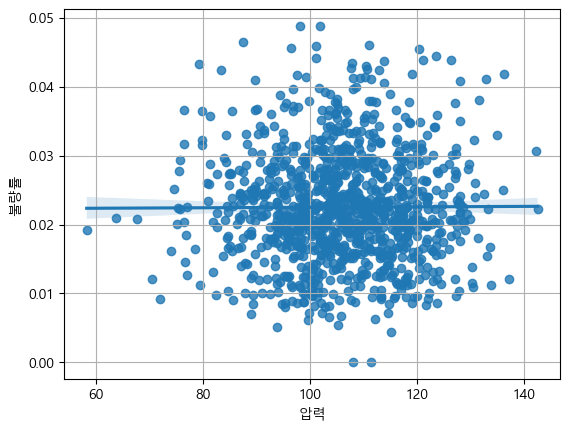

In [45]:
sns.regplot(data = df , x = '압력' , y = '불량률' , ci = 90)
plt.grid()
plt.show()

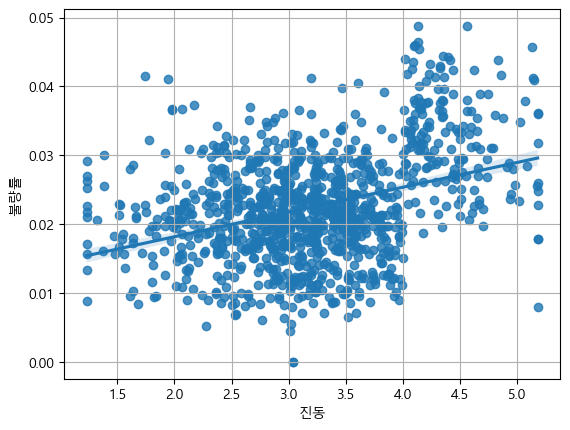

In [46]:
sns.regplot(data = df , x = '진동' , y = '불량률' , ci = 90)
plt.grid()
plt.show()

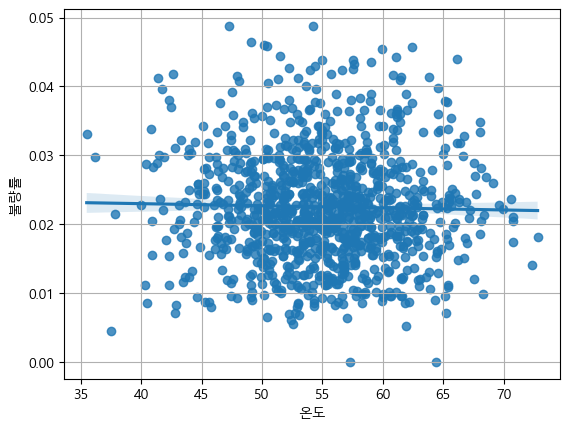

In [47]:
sns.regplot(data = df , x = '온도' , y = '불량률' , ci = 90)
plt.grid()
plt.show()

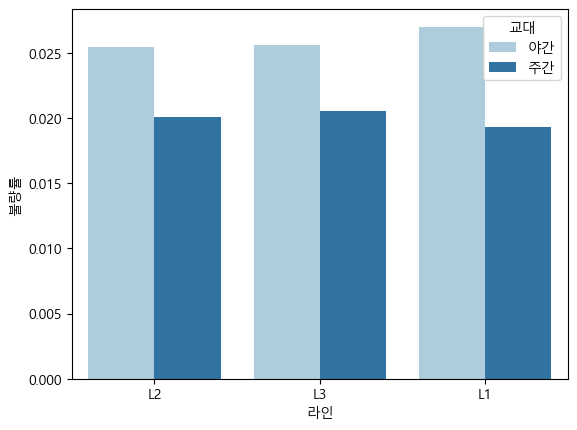

In [41]:
sns.barplot(data = df , x = '라인' , y = '불량률' , hue = '교대' , palette = 'Paired' ,errorbar = None)
plt.show()

<Axes: xlabel='불량률', ylabel='Density'>

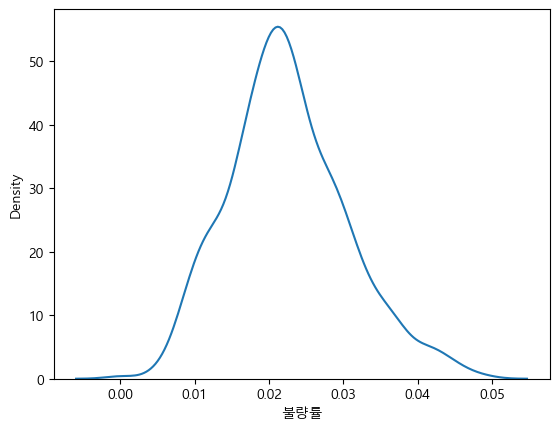

In [42]:
sns.kdeplot(data = df , x = '불량률')  # 커널 밀도 함수 